# **TAREA 3 DATA ANALYSIS AND MACHINE LEARNING**


**Nombre:** Álvaro Contreras Zúñiga

**Matrícula:** 2021433031

## Importación de librerías y parche necesario

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, re, math

# EFA / CFA
from factor_analyzer import FactorAnalyzer
import semopy

# parche compatibilidad factor_analyzer 
import inspect
import factor_analyzer.factor_analyzer as _ff
from sklearn.utils import check_array as _check_array
_ca_params = inspect.signature(_check_array).parameters
if "ensure_all_finite" in _ca_params and "force_all_finite" not in _ca_params:
    def _patched_check_array(X, **kwargs):
        if "force_all_finite" in kwargs:
            kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
        return _check_array(X, **kwargs)
    _ff.check_array = _patched_check_array

# Machine Learning
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     cross_val_score, RepeatedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              StackingClassifier)
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay, silhouette_score)
from xgboost import XGBClassifier

# Texto
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
np.set_printoptions(suppress=True)
%matplotlib inline

## **PREGUNTA 1**: Carga, limpieza y estadística descriptiva

**Enunciado:** Cargue la base de datos y realice los ajustes necesarios (missing values, recodificar variables, etc.). Identifique los tipos de datos, realice estadísticas descriptivas sobre las variables importantes (distribuciones, datos faltantes, outliers) y limpie las variables cuando sea necesario.

In [2]:
df = pd.read_csv("junaeb2n.csv", delimiter=",", decimal=".")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (41854, 24)


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,2,2,1,2,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,1,4,1,1,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,2,3,2,2,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.05,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,2.0,1,16.0,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.05,1,1,1,1,1,1,1,1,3,1,1,1,1,1,1,1.0,1,17.0,15,0,"Exhibe un perfil socioemocional muy solido, de..."


In [3]:
# Tipos de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41854 entries, 0 to 41853
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        41854 non-null  int64  
 1   edad        41854 non-null  int64  
 2   imce        41854 non-null  float64
 3   vive_padre  41854 non-null  int64  
 4   vive_madre  41854 non-null  int64  
 5   sk1         41854 non-null  int64  
 6   sk2         41854 non-null  int64  
 7   sk3         41854 non-null  int64  
 8   sk4         41854 non-null  int64  
 9   sk5         41854 non-null  int64  
 10  sk6         41854 non-null  int64  
 11  sk7         41854 non-null  int64  
 12  sk8         41854 non-null  int64  
 13  sk9         41854 non-null  int64  
 14  sk10        41854 non-null  int64  
 15  sk11        41854 non-null  int64  
 16  sk12        41854 non-null  int64  
 17  sk13        41854 non-null  int64  
 18  act_fisica  40419 non-null  float64
 19  area        41854 non-null  int64  


**Tipos de variables presentes en la base:**
- **Continuas**: "imce" (z-score de IMC), "edad" (en meses), "educm", "educp" (años de escolaridad).

- **Ordinales** (Likert 1–5): "sk1"–"sk13" (habilidades socioemocionales) y "act_fisica" (frecuencia de actividad física).

- **Categóricas / binarias:** "sexo" (1=mujer), "area" (1=urbana, 0=rural), "vive_padre", "vive_madre", "madre_work" (-1 labor doméstica, 0 desempleada, 1 empleada).

- **Texto**: "narrative" (texto generado a partir de "sk1"–"sk13").

In [4]:
# Datos faltantes
miss = df.isnull().sum()
print("Valores faltantes por columna (solo > 0):")
print(miss[miss > 0])
print("\n% del total:")
print((miss[miss > 0] / len(df) * 100).round(2))

Valores faltantes por columna (solo > 0):
act_fisica    1435
educm          551
dtype: int64

% del total:
act_fisica    3.43
educm         1.32
dtype: float64


In [5]:
# Categorías poco frecuentes / a recodificar 
for c in ["sexo", "area", "vive_padre", "vive_madre", "madre_work", "act_fisica"]:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False).sort_index(), "\n")

--- sexo ---
sexo
0    18737
1    23117
Name: count, dtype: int64 

--- area ---
area
0     3699
1    38155
Name: count, dtype: int64 

--- vive_padre ---
vive_padre
0    11733
1    30105
2       16
Name: count, dtype: int64 

--- vive_madre ---
vive_madre
0     1529
1    40255
2       70
Name: count, dtype: int64 

--- madre_work ---
madre_work
-1    17026
 0     4309
 1    20519
Name: count, dtype: int64 

--- act_fisica ---
act_fisica
1.0     6241
2.0    14211
3.0    14620
4.0     2084
5.0     3263
NaN     1435
Name: count, dtype: int64 



In [6]:
# Estadística descriptiva de variables continuas (con asimetría y curtosis) 
cont = ["imce", "edad", "educm", "educp"]
desc = df[cont].describe().T
desc["skew"] = df[cont].skew()
desc["kurt"] = df[cont].kurt()
desc[["mean", "std", "min", "50%", "max", "skew", "kurt"]].round(2)

,mean,std,min,50%,max,skew,kurt
imce,1.01,1.38,-5.02,0.97,5.04,0.00,0.27
edad,83.07,3.99,62.00,82.00,107.00,2.29,6.63
educm,12.98,3.37,0.00,13.00,22.00,-0.15,1.09
educp,12.90,3.46,0.00,13.00,22.00,-0.07,1.05


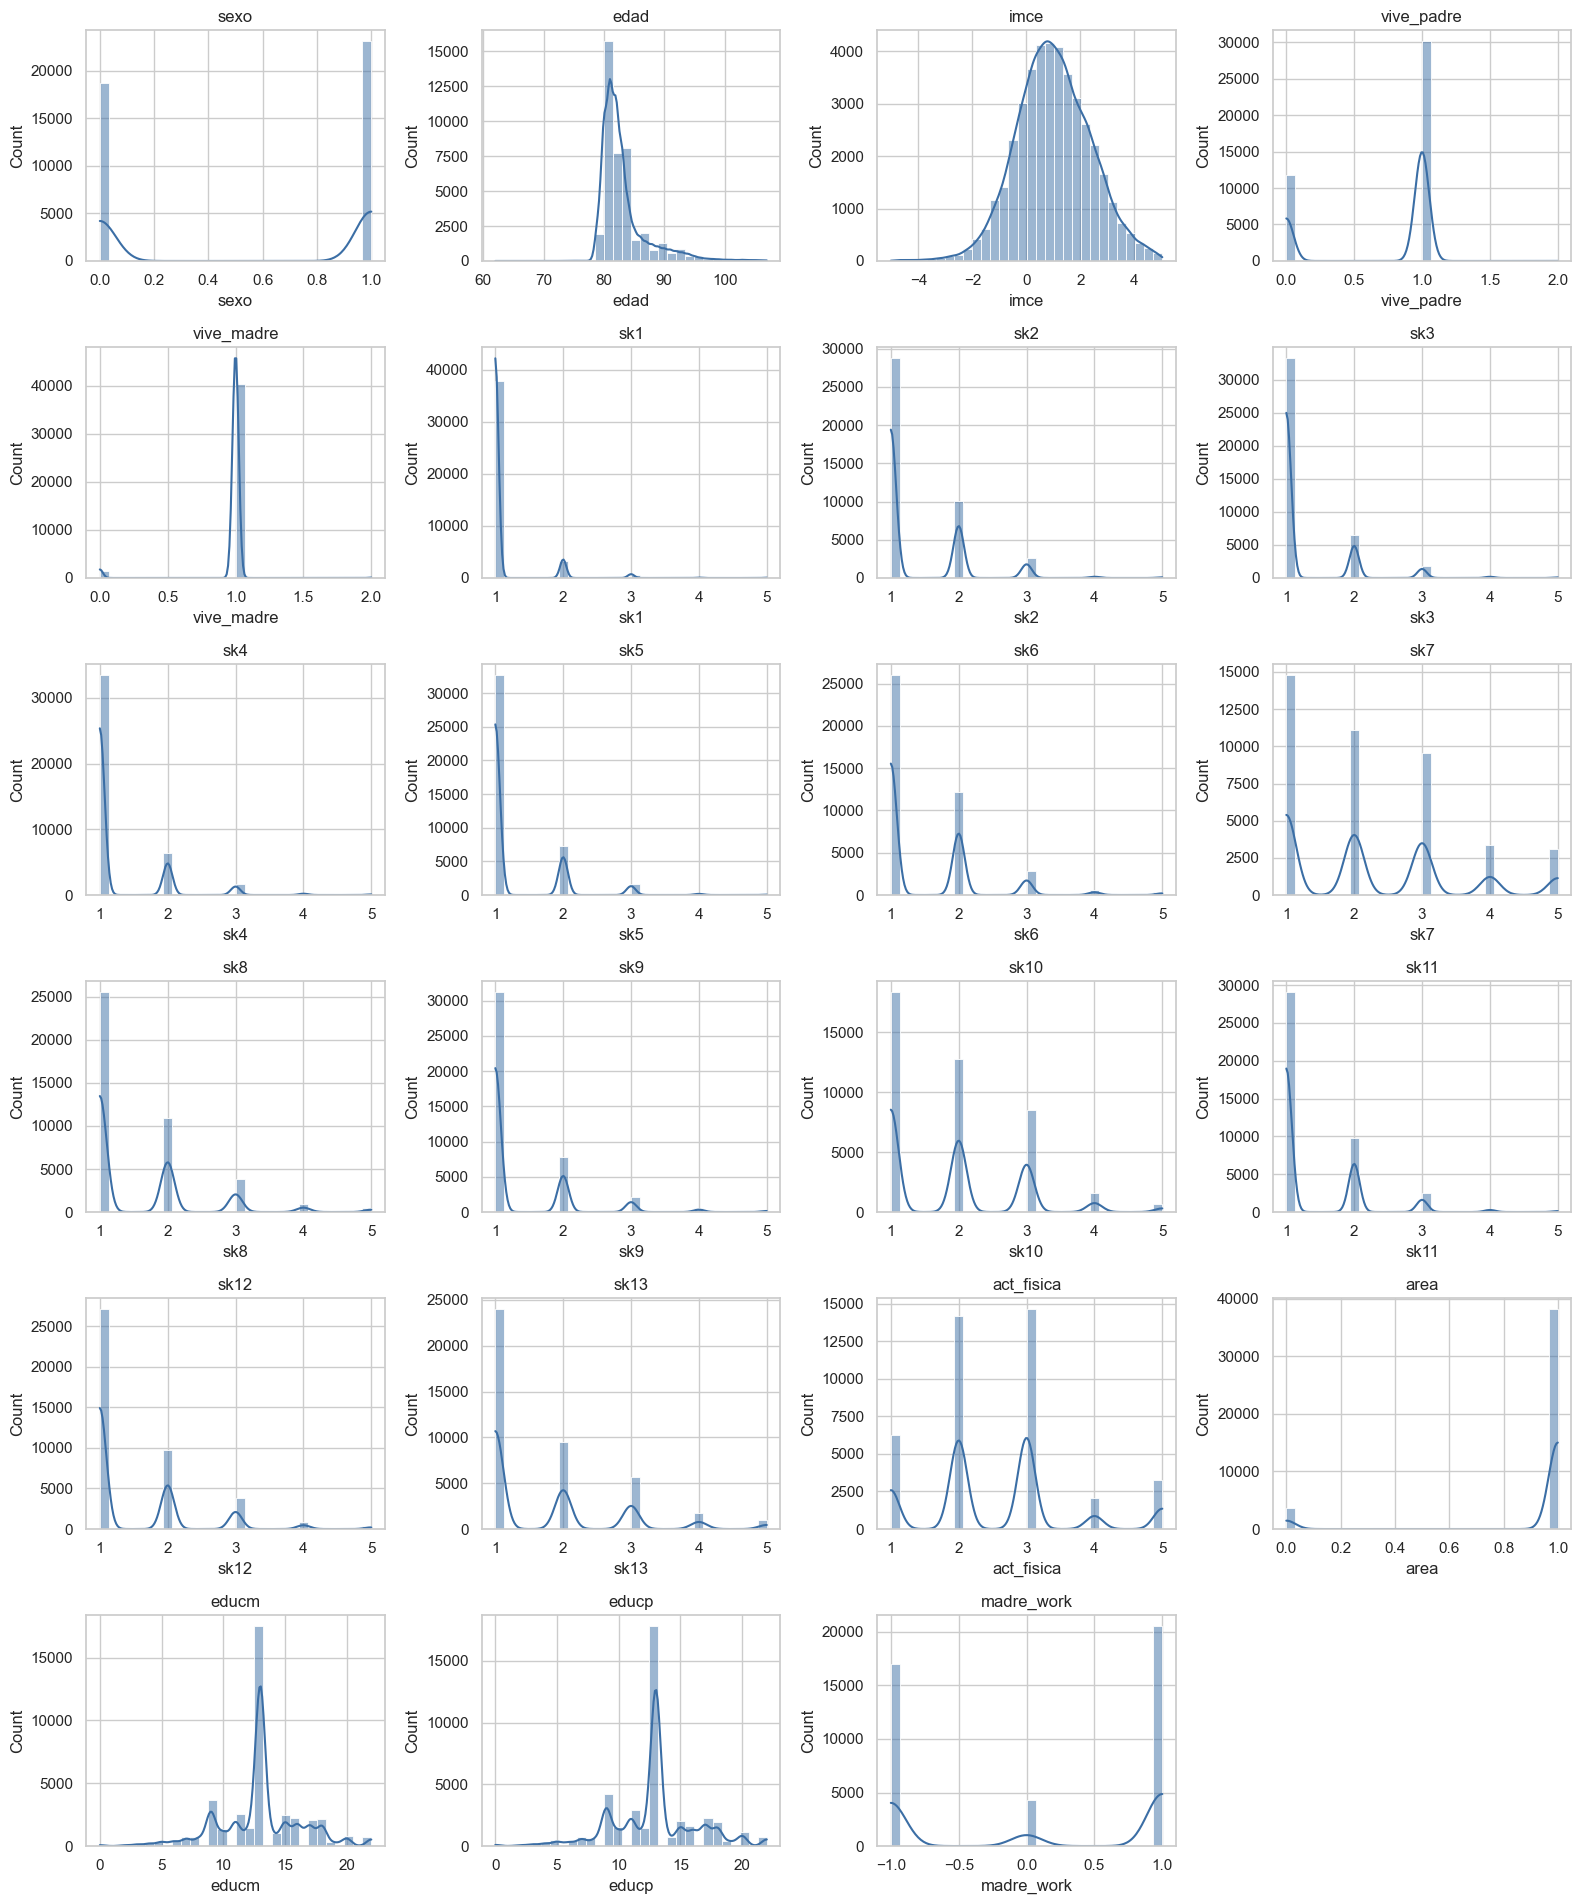

In [7]:
# Distribuciones de todas las variables numéricas 
num_cols = df.select_dtypes(include="number").columns
cols_per_row = 4
n_rows = math.ceil(len(num_cols) / cols_per_row)
fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30, color="#3b6ea5")
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

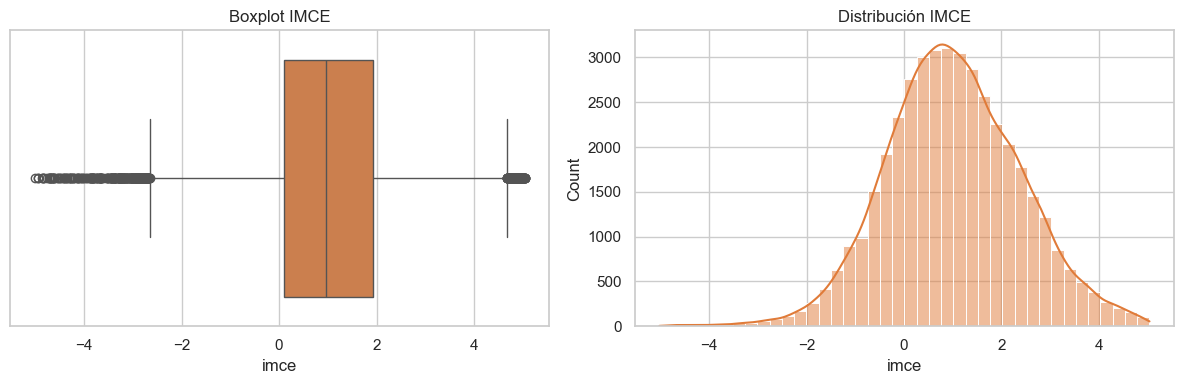

|imce| > 3: 3356 casos (8.0%)
|imce| > 4: 838 casos (2.0%)
|imce| > 4.5: 308 casos (0.7%)


In [8]:
#  Outliers en imce (z-score de IMC): boxplot y conteo de colas 
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["imce"], ax=ax[0], color="#e07b39"); ax[0].set_title("Boxplot IMCE")
sns.histplot(df["imce"], bins=40, kde=True, ax=ax[1], color="#e07b39"); ax[1].set_title("Distribución IMCE")
plt.tight_layout(); plt.show()
for t in [3, 4, 4.5]:
    print(f"|imce| > {t}: {(df['imce'].abs() > t).sum()} casos "
          f"({(df['imce'].abs() > t).mean()*100:.1f}%)")

In [9]:
# ============== LIMPIEZA ==============
df_clean = df.copy()

# Eliminar filas con faltantes (act_fisica ~3.4%, educm ~1.3%; en total < 5%)
df_clean = df_clean.dropna(subset=["act_fisica", "educm"])

# Recodificar categorías marginales en vive_padre / vive_madre: el valor 2 ("más de un padre/madre") es residual (16 y 70 casos) asi q se descarta
df_clean = df_clean[(df_clean["vive_padre"] != 2) & (df_clean["vive_madre"] != 2)]

# imce: las colas extremas (|z|>4) son z-scores posibles en nutrición infantil (obesidad / desnutrición severa). No se eliminan, solo se documentan.

df_clean = df_clean.reset_index(drop=True)
print("Filas antes:", len(df), "| después:", len(df_clean),
      f"| removidas: {len(df) - len(df_clean)} ({(1-len(df_clean)/len(df))*100:.1f}%)")
df_clean[["imce", "edad", "educm", "educp"]].describe().round(2)

Filas antes: 41854 | después: 39815 | removidas: 2039 (4.9%)


,imce,edad,educm,educp
count,39815.00,39815.00,39815.00,39815.00
mean,1.01,83.02,13.02,12.95
std,1.38,3.94,3.37,3.45
min,-5.02,62.00,0.00,0.00
25%,0.10,81.00,11.00,11.00
50%,0.96,82.00,13.00,13.00
75%,1.93,84.00,15.00,14.00
max,5.04,107.00,22.00,22.00


La siguiente tabla resume los problemas detectados en la base y la decisión tomada en cada caso:

| Variable | Problema detectado | Decisión |
|---|---|---|
| act_fisica | 1.435 valores faltantes (≈3,4%) | Eliminar las filas con NaN |
| educm | 551 valores faltantes (≈1,3%) | Eliminar las filas con NaN |
| vive_padre | Categoría 2 ("más de un padre") residual: 16 casos | Descartar esos casos y dejar la variable binaria |
| vive_madre | Categoría 2 ("más de una madre") residual: 70 casos | Descartar esos casos y dejar la variable binaria |
| imce | Colas pesadas, ≈8% con \|z\|>3 | Conservar: son z-scores plausibles en nutrición infantil |
| sk1–sk13 | Escala Likert 1–5, sin faltantes | Sin cambios aquí; se recodifican en P2 |

**R (P1):** La base original tiene 41.854 observaciones y 24 columnas. Lo primero que se hizo fue revisar los tipos de datos con df.info(): se identificaron variables continuas ("imce", que es un puntaje z del índice de masa corporal, "edad" en meses; y los años de escolaridad "educm" y "educp"), variables ordinales en escala de 1 a 5 (los trece ítems socioemocionales "sk1"–"sk13" y la frecuencia de actividad física "act_fisica"), variables categóricas o binarias ("sexo", "area", "vive_padre", "vive_madre" y el target "madre_work") y una variable de texto "narrative".

En cuanto a los datos faltantes, solo "act_fisica" (≈3,4%) y "educm" (≈1,3%) presentan nulos, como en conjunto no llegan al 5% de la muestra y la base es grande, se optó por eliminar esas filas en lugar de imputar, imputar la mediana habría sido una alternativa válida, pero al tratarse de tan pocos casos eliminarlos no introduce sesgo apreciable y mantiene limpia "act_fisica", que se ocupará más adelante en el clustering. En "vive_padre" y "vive_madre" se observó que la categoría 2 (más de un padre o madre en el hogar) es marginal, con 16 y 70 casos respectivamente, por lo que se descartó para dejar variables binarias claras (vive o no vive en el hogar).

Respecto de los outliers, en "imce" se aprecia una distribución de colas pesadas, cerca de un 8% de los niños tiene \|z\|>3. Sin embargo, al ser un puntaje z del IMC, esos valores extremos son posibles y corresponden a casos de obesidad o desnutrición severa, que son justamente la población de mayor interés sanitario. Por eso se decidió conservarlos y mencionar esto, en lugar de recortarlos. Las variables continuas restantes no presentan valores imposibles (la edad va de 62 a 107 meses, es decir entre 5 y 9 años, y la escolaridad entre 0 y 22 años). Tras la limpieza quedan 39.815 observaciones, es decir se removió un 4,9% de las filas, y son las que se usan en el resto de la tarea.

Mirando las distribuciones de los histogramas, se observa que los ítems socioemocionales positivos (sk1–sk6 y sk8–sk13) están concentrados en el valor 1 (siempre), con cola hacia los valores altos, aunque algunos ítems (sk8, sk10, sk13) aparecen algo más repartidos. La excepción clara es sk7 (agresividad), el único ítem con una distribución repartida entre todos los niveles del 1 al 5, esto se entiende porque está codificado en sentido inverso y anticipa que se comporta distinto al resto. A diferencia de los ítems sk, act_fisica se concentra en los niveles 2 y 3, lo que es coherente con que mide frecuencia y no una conducta de tipo siempre/nunca. Entre las variables continuas, imce tiene una forma aproximadamente acampanada pero centrada en torno a 1 y no en 0: como es un puntaje z respecto de una referencia, esto sugiere que esta muestra está corrida cerca de una desviación estándar hacia arriba (más sobrepeso del esperado), algo que es coherente con la realidad nutricional infantil. La edad se concentra alrededor de los 80 meses (unos 6 a 7 años) con una cola hacia edades mayores, y la escolaridad de los padres (educm, educp) se agrupa en torno a los 12–13 años, es decir, enseñanza media completa.

## **PREGUNTA 2**: Análisis Factorial Exploratorio (EFA)

**Enunciado:** A partir de sk1–sk13 realice un EFA: determine el número óptimo de factores y reporte las variables asociadas a cada factor (factor loadings). Discuta si existen variables no informativas.
Hint: todas las variables deben estar en el mismo sentido lógico; si una característica es negativa debe invertirse para que todas representen aspectos positivos.

In [10]:
sk_cols = [f"sk{i}" for i in range(1, 14)]

# Diagnóstico de dirección: correlación de la única conducta NEGATIVA (sk7=agresividad)
# con el resto, en la escala original.
corr_raw = df_clean[sk_cols].corr()
print("Correlación de sk7 (agresividad) con el resto en escala original:")
print(corr_raw["sk7"].round(3))

Correlación de sk7 (agresividad) con el resto en escala original:
sk1     0.124
sk2     0.126
sk3     0.039
sk4     0.072
sk5     0.086
sk6     0.191
sk7     1.000
sk8     0.068
sk9     0.082
sk10    0.092
sk11    0.106
sk12    0.039
sk13    0.056
Name: sk7, dtype: float64


Antes de estimar el EFA dejamos todas las variables en el mismo sentido lógico. En la escala original los ítems positivos ("sk1"–"sk6", "sk8"–"sk13") usan 1=siempre,..., 5=nunca (número alto = menos conducta positiva), y el único ítem negativo, "sk7" (agresividad), usa 1=nunca,..., 5=siempre (número alto = más conducta negativa). En ambos casos número alto = peor, por eso "sk7" ya correlaciona positivamente con el resto (ver arriba). Para que todas midan un aspecto positivo con la lógica "más = mejor", invertimos todos los ítems con **x' = 6 − x**, así **sk7'** pasa a medir calma o ausencia de agresividad y queda alineado con los demás, dejando todas las cargas positivas sobre un mismo factor de competencia socioemocional.

In [11]:
# Invertir todos los ítems: 6 - x  (escala 'mayor = mejor', todas positivas)
df_sk = 6 - df_clean[sk_cols]
df_sk.describe().round(2).T[["mean", "min", "max"]]

,mean,min,max
sk1,4.89,1.0,5.0
sk2,4.61,1.0,5.0
sk3,4.74,1.0,5.0
sk4,4.74,1.0,5.0
sk5,4.73,1.0,5.0
sk6,4.51,1.0,5.0
sk7,3.75,1.0,5.0
sk8,4.44,1.0,5.0
sk9,4.66,1.0,5.0
sk10,4.12,1.0,5.0


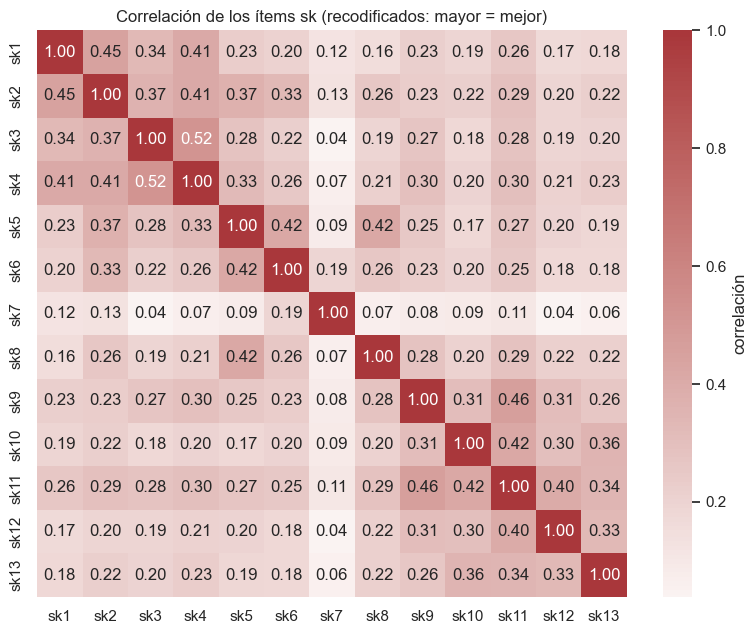

In [12]:
# Matriz de correlación recodificada (debería ser toda positiva)
plt.figure(figsize=(8, 6.5))
sns.heatmap(df_sk.corr(), annot=True, fmt=".2f", cmap="vlag", center=0,
            cbar_kws={"label": "correlación"})
plt.title("Correlación de los ítems sk (recodificados: mayor = mejor)")
plt.tight_layout(); plt.show()

Valores propios: [4.061 1.348 1.113 1.002 0.781 0.711 0.697 0.693 0.603 0.523 0.512 0.492
 0.465]

Factores con valor propio > 1 (criterio de Kaiser): 4
3er valor propio = 1.1129
4to valor propio = 1.0023  <-- prácticamente en el límite de 1.0


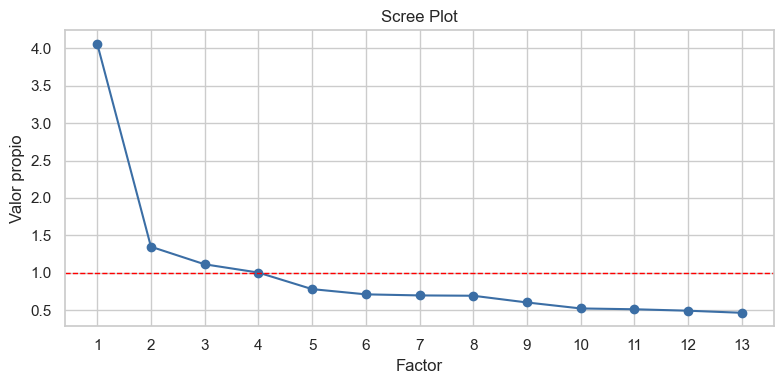

In [13]:
# Número de factores: valores propios (Kaiser) + scree plot 
fa_all = FactorAnalyzer(rotation=None, n_factors=13).fit(df_sk)
ev, _ = fa_all.get_eigenvalues()
print("Valores propios:", np.round(ev, 3))

n_kaiser = int((ev > 1).sum())
print(f"\nFactores con valor propio > 1 (criterio de Kaiser): {n_kaiser}")
print(f"3er valor propio = {ev[2]:.4f}")
print(f"4to valor propio = {ev[3]:.4f}  <-- prácticamente en el límite de 1.0")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 14), ev, "o-", color="#3b6ea5")
plt.axhline(1, ls="--", color="red", lw=1)
plt.title("Scree Plot"); plt.xlabel("Factor"); plt.ylabel("Valor propio")
plt.xticks(range(1, 14)); plt.tight_layout(); plt.show()

El criterio de Kaiser cuenta cuatro valores propios mayores que 1, pero el cuarto es ≈1.0, es decir está justo sobre la línea de corte. Para decidir entre 3 y 4 factores conviene mirar también qué estructura entrega cada solución, ya que un cuarto factor solo se justifica si agrega un factor con una interpretación clara. A continuación se compara la solución de 4 factores con la de 3:

In [14]:
# ¿Por qué 3 y no 4? Veamos qué ítems agrupa la solución de 4 factores.
fa4 = FactorAnalyzer(n_factors=4, rotation="varimax").fit(df_sk)
L4 = pd.DataFrame(fa4.loadings_, index=sk_cols, columns=["F1", "F2", "F3", "F4"])
asign4 = L4.abs().idxmax(axis=1)
print("Ítems por factor en la solución de 4 factores (carga dominante):")
for f in ["F1", "F2", "F3", "F4"]:
    items = [v for v in sk_cols if asign4[v] == f]
    print(f"  {f}: {items}  (n={len(items)})")
print("\nCargas (4 factores):")
display(L4.round(3))

Ítems por factor en la solución de 4 factores (carga dominante):
  F1: ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']  (n=5)
  F2: ['sk1', 'sk2', 'sk3', 'sk4']  (n=4)
  F3: ['sk5', 'sk6', 'sk8']  (n=3)
  F4: ['sk7']  (n=1)

Cargas (4 factores):


,F1,F2,F3,F4
sk1,0.162,0.506,0.052,0.347
sk2,0.165,0.475,0.255,0.401
sk3,0.203,0.632,0.165,-0.020
sk4,0.211,0.685,0.187,0.052
sk5,0.133,0.218,0.754,0.135
sk6,0.180,0.167,0.413,0.310
sk7,0.065,0.025,0.070,0.292
sk8,0.282,0.111,0.456,0.077
sk9,0.511,0.214,0.189,0.044
sk10,0.556,0.084,0.072,0.178


In [15]:
# EFA con 3 factores y rotación varimax 
fa = FactorAnalyzer(n_factors=3, rotation="varimax").fit(df_sk)
loadings = pd.DataFrame(fa.loadings_, index=sk_cols, columns=["F1", "F2", "F3"])
print("Cargas factoriales (varimax):")
display(loadings.round(3))

# Factor de mayor carga (en valor absoluto) para cada variable
asignacion = loadings.abs().idxmax(axis=1)
maxload = loadings.abs().max(axis=1)
resumen = pd.DataFrame({"factor_dominante": asignacion, "carga_max": maxload.round(3)})
print("\nAsignación variable -> factor:")
display(resumen)

Cargas factoriales (varimax):


,F1,F2,F3
sk1,0.169,0.546,0.150
sk2,0.169,0.522,0.351
sk3,0.187,0.590,0.159
sk4,0.194,0.673,0.193
sk5,0.118,0.214,0.729
sk6,0.174,0.207,0.485
sk7,0.073,0.080,0.145
sk8,0.265,0.101,0.474
sk9,0.498,0.214,0.204
sk10,0.553,0.120,0.129



Asignación variable -> factor:


,factor_dominante,carga_max
sk1,F2,0.546
sk2,F2,0.522
sk3,F2,0.590
sk4,F2,0.673
sk5,F3,0.729
sk6,F3,0.485
sk7,F3,0.145
sk8,F3,0.474
sk9,F1,0.498
sk10,F1,0.553


In [16]:
# Comunalidades y varianza explicada 
com = pd.Series(fa.get_communalities(), index=sk_cols, name="comunalidad").round(3)
print("Comunalidades (proporción de varianza del ítem explicada por los factores):")
display(com.sort_values())

var = pd.DataFrame(fa.get_factor_variance(),
                   index=["Varianza (SS loadings)", "Proporción", "Proporción acumulada"],
                   columns=["F1", "F2", "F3"]).round(3)
print("\nVarianza explicada por factor:")
display(var)

Comunalidades (proporción de varianza del ítem explicada por los factores):


sk7     0.033
sk13    0.286
sk8     0.305
sk6     0.308
sk12    0.310
sk9     0.336
sk10    0.337
sk1     0.349
sk3     0.408
sk2     0.424
sk11    0.523
sk4     0.528
sk5     0.591
Name: comunalidad, dtype: float64


Varianza explicada por factor:


,F1,F2,F3
Varianza (SS loadings),1.762,1.618,1.358
Proporción,0.136,0.124,0.104
Proporción acumulada,0.136,0.260,0.364


**R (P2):** Tal como se explica en las slides de clases, el análisis factorial exploratorio se diferencia del PCA en que no usa toda la variabilidad de la data, sino que separa cada variable observada en dos componentes: una parte de variable latente más un error de medida (ruido). La idea aquí fue entonces buscar los factores latentes que están detrás de los trece ítems socioemocionales.

Antes de estimar nada hubo que dejar todas las variables en el mismo sentido lógico, como pide el enunciado. En la escala original los doce ítems positivos ("sk1"–"sk6", "sk8"–"sk13") están codificados como 1=siempre,..., 5=nunca, mientras que el único ítem negativo, "sk7" (agresividad), está al revés (1=nunca ,..., 5=siempre). Al revisar las correlaciones se vio que en la escala original "sk7" ya correlaciona positivamente con el resto, porque en todos los casos un número alto representa algo peor. Para que todas las variables midieran un aspecto positivo con la lógica "mayor = mejor", se invirtieron todos los ítems con la transformación **x' = 6 − x**. Así **sk7** pasa a medir ausencia de agresividad y queda alineado con los demás, dejando una matriz de correlación completamente positiva, que es la situación deseada para el EFA.

Para determinar el número óptimo de factores se usaron los mismos criterios que en PCA: los valores propios y el scree plot. Aquí hay un punto que conviene aclarar, porque el criterio de Kaiser (retener los factores con valor propio mayor que 1) cuenta cuatro, los tres primeros valores propios son claramente mayores que 1 (4,061, 1,348 y 1,113), pero el cuarto es 1,002, es decir, está prácticamente en la línea de corte. Se puede ver que en el scree plot ese cuarto punto cae prácticamente sobre la línea de 1,0, y la única caída fuerte ocurre después del primer factor, sin un quiebre posterior que justifique abrir una cuarta dimensión y en el material de la clase se indica que el número de factores se decide combinando los valores propios, el scree plot y la varianza explicada, no aplicando Kaiser de forma mecánica.

Para confirmarlo se estimó también la solución de cuatro factores, y se obtuvo que los tres factores anteriores se mantienen prácticamente idénticos (Curiosidad con "sk9"–"sk13", Afecto con "sk1"–"sk4" y Habilidades sociales con "sk5", "sk6" y "sk8"), y el cuarto factor no agrupa un constructo nuevo: queda compuesto únicamente por "sk7", es decir, un factor de un solo ítem. En otras palabras, el cuarto factor que sugiere Kaiser no representa una dimensión real, sino que simplemente aísla a la variable más ruidosa, la misma "sk7" que ya tenía la comunalidad más baja. Y desde el punto de vista del CFA es inviable, en las slides se dice que deben tener al menos tres medidas por factor, y un factor con un único indicador ni siquiera queda identificado para estimarse. Por todo lo anterior se eligió una solución de tres factores, que es la que respaldan el scree plot y la interpretabilidad, y la única que permite construir un CFA limpio.

Estimando el EFA con tres factores y rotación varimax, las variables se agrupan de la siguiente forma según su carga dominante:

**Factor 1:** "sk9", "sk10", "sk11", "sk12" y "sk13". Todos estos ítems tienen que ver con el interés del niño por aprender y explorar (hace preguntas, le interesan los libros y su entorno, arma y desarma cosas, tiene expresiones artísticas), por lo que se asocia a la curiosidad o intereses cognitivos. Dentro de este grupo la carga más alta es la de "sk11" (0,66), seguida de "sk10" (0,55) y "sk12" (0,53).

**Factor 2:** "sk1", "sk2", "sk3" y "sk4", ligados al afecto y la expresión emocional (muestra afecto a padres y pares, expresa sentimientos y usa gestos), con "sk4" como la carga más fuerte (0,67) y "sk3" en 0,59.

**Factor 3:** "sk5", "sk6" y "sk8", que apuntan a las habilidades sociales y el juego (juega con otros, comparte sus cosas, participa en juegos grupales), donde "sk5" carga muy fuerte (0,73). En conjunto los tres factores explican un 36,4% de la varianza total (13,6%, 12,4% y 10,4% respectivamente).

En cuanto a variables no informativas, el caso más claro es "sk7" (agresividad). Su carga máxima es muy baja (0,145) y tiene la comunalidad más baja de todos los ítems por lejos: apenas 0,033, frente a valores de entre 0,29 y 0,59 para el resto. Es decir, los factores explican prácticamente nada de su varianza. En la práctica no se asocia de forma clara a ningún factor, por lo que se decidió dejarlo fuera del modelo confirmatorio de la P3. El resto de los ítems, en cambio, carga de manera limpia en un único factor.

## **PREGUNTA 3**: Análisis Factorial Confirmatorio (CFA)

**Enunciado:** Con los resultados de P2, proponga un CFA donde cada variable se asocia a un solo factor. Asigne un nombre a cada factor (concepto común), reporte la importancia de cada medida a su factor e indique la correlación entre factores (loadings). Guarde sus predicciones.

In [17]:
# Trabajamos con los ítems recodificados (mayor = mejor).
df_cfa = df_clean.copy()
df_cfa[sk_cols] = df_sk            # reemplazamos por la versión invertida
# sk7 se excluye por no ser informativo (P2).

# Modelo de medida: cada ítem carga en UN solo factor (estructura simple)
modelo_cfa = '''
# measurement model
Curiosidad     =~ sk9 + sk10 + sk11 + sk12 + sk13
Afecto         =~ sk1 + sk2 + sk3 + sk4
Habilid_social =~ sk5 + sk6 + sk8
'''
cfa = semopy.Model(modelo_cfa)
res = cfa.fit(df_cfa)
print(res)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.147
Number of iterations: 38
Params: 1.323 1.232 1.087 1.283 1.879 1.640 1.809 1.019 1.142 0.051 0.054 0.060 0.161 0.168 0.096 0.098 0.621 0.210 0.450 0.726 0.247 0.203 0.167 0.155 0.373 0.484 0.287


In [18]:
# Importancia de cada medida (cargas estandarizadas) 
# En semopy.inspect(), las cargas de medida aparecen con el operador '~'
# (el indicador regresado sobre el factor): lval = ítem, rval = factor.
params = cfa.inspect(std_est=True)
loads = params[params["op"] == "~"][["rval", "lval", "Estimate", "Est. Std", "p-value"]]
loads.columns = ["Factor", "Item", "Carga", "Carga_std", "p-value"]
print("--- Cargas factoriales (importancia de cada ítem en su factor) ---")
display(loads.reset_index(drop=True))

--- Cargas factoriales (importancia de cada ítem en su factor) ---


,Factor,Item,Carga,Carga_std,p-value
0,Curiosidad,sk9,1.000000,0.599835,-
1,Curiosidad,sk10,1.322946,0.559145,0.0
2,Curiosidad,sk11,1.231780,0.733513,0.0
3,Curiosidad,sk12,1.086900,0.545420,0.0
4,Curiosidad,sk13,1.282781,0.517386,0.0
5,Afecto,sk1,1.000000,0.585846,-
6,Afecto,sk2,1.878586,0.648981,0.0
7,Afecto,sk3,1.640045,0.634642,0.0
8,Afecto,sk4,1.809487,0.706717,0.0
9,Habilid_social,sk5,1.000000,0.720970,-


In [19]:
# Correlación entre factores (loadings entre latentes) 
cov = params[(params["op"] == "~~") &
             (params["lval"] != params["rval"]) &
             (params["lval"].isin(["Curiosidad","Afecto","Habilid_social"])) &
             (params["rval"].isin(["Curiosidad","Afecto","Habilid_social"]))]
print("Correlaciones entre factores latentes")
display(cov[["lval", "rval", "Est. Std", "p-value"]]
        .rename(columns={"lval":"Factor A","rval":"Factor B","Est. Std":"correlación"})
        .reset_index(drop=True))

Correlaciones entre factores latentes


,Factor A,Factor B,correlación,p-value
0,Afecto,Curiosidad,0.599859,0.0
1,Afecto,Habilid_social,0.648554,0.0
2,Habilid_social,Curiosidad,0.586237,0.0


In [20]:
# Índices de ajuste (TLI, CFI, RMSEA) 
stats = semopy.calc_stats(cfa)
display(stats[["DoF", "chi2", "CFI", "TLI", "RMSEA"]].round(3))

,DoF,chi2,CFI,TLI,RMSEA
Value,51,5860.524,0.947,0.931,0.053


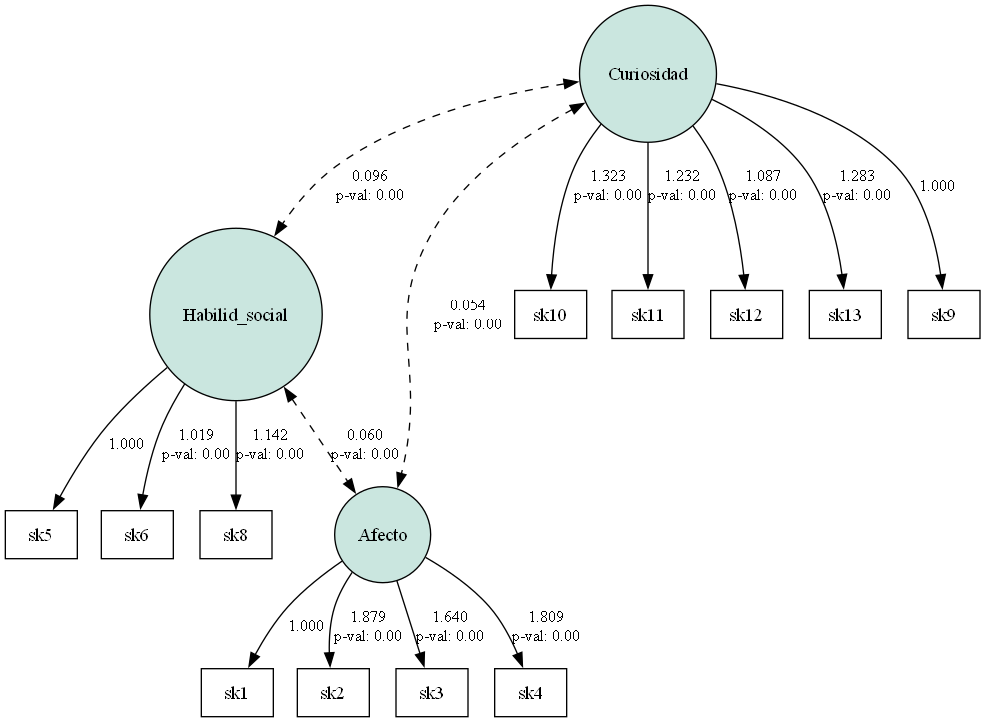

In [21]:
# Diagrama del modelo (requiere graphviz instalado)
try:
    g = semopy.semplot(cfa, "cfa_model.png", plot_covs=True)
    from IPython.display import Image
    display(Image("cfa_model.png"))
except Exception as e:
    print("semplot omitido (graphviz no disponible):", e)

In [22]:
# GUARDAR PREDICCIONES: factor scores de cada individuo 
factores = cfa.predict_factors(df_cfa)
factores.columns = ["Curiosidad", "Afecto", "Habilid_social"]
factores.index = df_cfa.index

# Adjuntamos los scores a la base limpia y persistimos en disco
df_clean = df_clean.join(factores)
factores.to_csv("factor_scores.csv", index=False)
print("Predicciones (factor scores) guardadas en 'factor_scores.csv'")
display(df_clean[["Curiosidad", "Afecto", "Habilid_social"]].describe().round(3))

Predicciones (factor scores) guardadas en 'factor_scores.csv'


,Curiosidad,Afecto,Habilid_social
count,39815.000,39815.000,39815.000
mean,0.000,0.000,0.000
std,0.200,0.354,0.349
min,-1.945,-2.733,-3.007
25%,-0.062,-0.174,-0.151
50%,0.080,0.109,0.124
75%,0.136,0.265,0.264
max,0.150,0.342,0.303


**R (P3):** Siguiendo lo visto en clases, el CFA es un modelo estructural de carácter confirmatorio, a diferencia del EFA, aquí ya se definen de antemano las asociaciones entre cada medida y su factor, se le da una interpretación a cada variable latente y luego se juzga la validez del modelo según su ajuste a la data y la minimización de los errores al cuadrado. A partir de la estructura encontrada en la P2 se propuso un modelo de estructura simple, donde cada ítem carga en un único factor, dejando fuera "sk7" por no ser informativo.

Los tres factores se nombraron según el concepto común de sus ítems: Curiosidad (intereses cognitivos y exploratorios, "sk9"–"sk13" (5 items)), Afecto(afecto y expresión emocional, "sk1"–"sk4"(4 items)) y Habilidades sociales (juego e interacción con pares, "sk5", "sk6", "sk8"(3 items)). 

Sobre la importancia de cada medida, el CFA entrega una estructura relacional que permite ver la relación señal-ruido (signal-to-noise) de cada ítem con su factor. En los resultados todas las cargas estandarizadas son positivas y significativas (p<0,001) y se ubican en un rango, entre 0,52 y 0,73, lo que indica que cada ítem aporta señal coherente a su factor. Las cargas más altas identifican los ítems "ancla", que son los que mejor representan a cada factor: "sk11" (0,73) en Curiosidad, "sk4" (0,71) en Afecto y "sk5" (0,72) en Habilidades sociales.

En cuanto a la correlación entre factores, conviene notar una diferencia con el EFA, la rotación varimax de la P2 impone factores ortogonales (no correlacionados), pero el CFA estima libremente la covarianza entre las variables latentes, al hacerlo, los tres factores aparecen positivamente correlacionados entre sí y de forma significativa (Curiosidad–Afecto 0,60, Curiosidad–Habilidades sociales 0,59 y Afecto–Habilidades sociales 0,65, todas con p<0,001). Esto tiene sentido, un niño con mejor desarrollo en un área tiende a tenerlo también en las otras, lo que sugiere un factor socioemocional más general por detrás.

El ajuste se evaluó con los índices  (CFI, TLI y RMSEA). El modelo entrega un buen ajuste: CFI 0,947 y TLI 0,931, ambos por sobre el umbral de 0,90, y un RMSEA de 0,053, por debajo de 0,06, es decir, la estructura de tres factores propuesta reproduce bien la matriz de covarianzas observada (el χ² es alto, 5.860 con 51 grados de libertad, pero eso es esperable con casi 40.000 observaciones, ya que el test de χ² es muy sensible al tamaño muestral, por eso se privilegian los índices CFI/TLI/RMSEA). Finalmente, una vez estimados los pesos se puede invertir el modelo para predecir los factores latentes de cada individuo, y esto es lo que se hizo con predict_factors, y esas predicciones (los tres scores latentes por niño) se guardaron en "factor_scores.csv" para usarlas como features en la P4 y la P5.

## **PREGUNTA 4**: Random Forest para clasificar madre_work

**Enunciado:** Usando los features del modelo de P3 (los tres factor scores), entrene un Random Forest para clasificar madre_work. Excluya a las personas desempleadas (categoría minoritaria, 0). Incluya optimización de hiperparámetros y validación por pliegues (k-fold).

In [23]:
# Target: madre_work, excluyendo desempleadas (0). Problema binario.

data = df_clean[df_clean["madre_work"] != 0].copy()
target = (data["madre_work"] == 1).astype(int)        # 1 = empleada ; 0 = labor doméstica
features = data[["Curiosidad", "Afecto", "Habilid_social"]]   # features del modelo de la P3

print("N =", len(data), "| features:", list(features.columns))
print("Distribución del target (1=empleada, 0=labor doméstica):")
print(target.value_counts(normalize=True).round(3))
baseline = max(target.mean(), 1 - target.mean())
print(f"Baseline (clase mayoritaria) = {baseline:.4f}")

# Split y estandarización 
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

N = 35688 | features: ['Curiosidad', 'Afecto', 'Habilid_social']
Distribución del target (1=empleada, 0=labor doméstica):
madre_work
1    0.555
0    0.445
Name: proportion, dtype: float64
Baseline (clase mayoritaria) = 0.5549


In [24]:
# Random Forest base (n_estimators=100)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
confusion_matrix(y_test, y_pred)

Accuracy: 0.5284393387503502


array([[1229, 3581],
       [1468, 4429]])

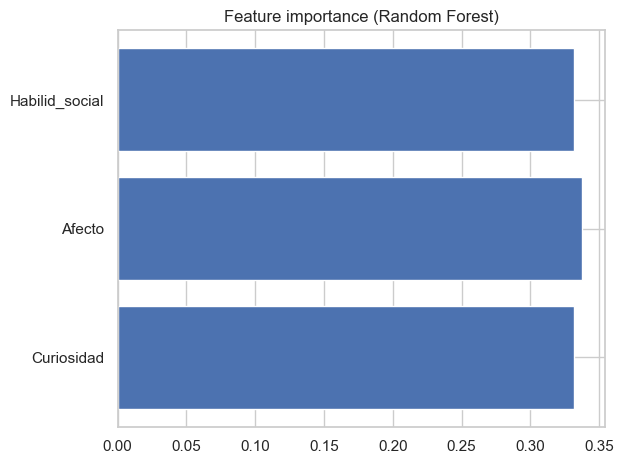

In [25]:
# Importancia de los features 
plt.barh(features.columns, rf.feature_importances_)
plt.title("Feature importance (Random Forest)"); plt.tight_layout(); plt.show()

In [26]:
# Ajuste de hiperparámetros con GridSearchCV (k-fold)
# La grilla se adapta a que aquí hay solo 3 features (max_features <= 3).
param_grid = {
    "bootstrap": [True],
    "max_depth": [6, 16, None],
    "max_features": [1, 2, 3],
    "min_samples_leaf": [1, 20, 50],
    "n_estimators": [100, 200],
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)
print("Mejores hiperparámetros:", grid_search.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 6, 'max_features': 1, 'min_samples_leaf': 1, 'n_estimators': 200}


In [27]:
# Tabla resumen de la búsqueda 
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(
    results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("config")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]].head(8)

,params,rank_test_score,mean_test_score,std_test_score
config,,,,
True_6_1_1_200,"{'bootstrap': True, 'max_depth': 6, 'max_featu...",1,0.560786,0.002352
True_6_1_1_100,"{'bootstrap': True, 'max_depth': 6, 'max_featu...",2,0.560266,0.002351
True_6_1_50_200,"{'bootstrap': True, 'max_depth': 6, 'max_featu...",3,0.560226,0.003180
True_6_1_50_100,"{'bootstrap': True, 'max_depth': 6, 'max_featu...",4,0.560106,0.002825
True_6_3_1_200,"{'bootstrap': True, 'max_depth': 6, 'max_featu...",5,0.559545,0.002705
True_6_3_1_100,"{'bootstrap': True, 'max_depth': 6, 'max_featu...",6,0.559425,0.004136
True_6_1_20_200,"{'bootstrap': True, 'max_depth': 6, 'max_featu...",7,0.559345,0.003156
True_6_2_1_200,"{'bootstrap': True, 'max_depth': 6, 'max_featu...",8,0.559305,0.002952


Accuracy test (RF tuneado): 0.5509
Baseline:                   0.5549

                 precision    recall  f1-score   support

labor doméstica       0.67      0.00      0.00      4810
       empleada       0.55      1.00      0.71      5897

       accuracy                           0.55     10707
      macro avg       0.61      0.50      0.36     10707
   weighted avg       0.60      0.55      0.39     10707



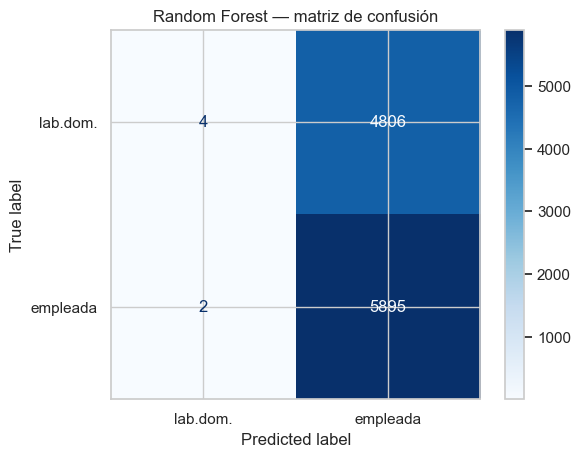

In [28]:
# Re-ajuste con los mejores hiperparámetros y evaluación final
best_rf = grid_search.best_estimator_
pred_rf = best_rf.predict(X_test)
print(f"Accuracy test (RF tuneado): {accuracy_score(y_test, pred_rf):.4f}")
print(f"Baseline:                   {baseline:.4f}\n")
print(classification_report(y_test, pred_rf, target_names=["labor doméstica", "empleada"]))

cm = confusion_matrix(y_test, pred_rf, labels=best_rf.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=["lab.dom.", "empleada"]).plot(cmap=plt.cm.Blues)
plt.title("Random Forest — matriz de confusión"); plt.show()

**R (P4):** Para esta parte se entrenó un Random Forest usando como features los tres factor scores guardados en la P3. Aqui se tiene presente que a diferencia de los modelos vistos antes en el curso, el machine learning se basa en el ajuste de la predicción fuera de muestra y no permite hablar de causalidad ni de efectos, por eso aquí no se interpretan coeficientes, sino que se reporta el desempeño predictivo y la importancia relativa de los features.

El Random Forest se construye con sub-muestras con reemplazo (bootstrap o bagging), entrenando en cada una un árbol donde los nodos se segmentan con medidas de información como entropía o Gini, para luego combinar la predicción de todos los árboles. Para el ajuste de los hiperparametros lo que se hizo fue una búsqueda por grilla con **GridSearchCV** sobre max_depth, max_features, min_samples_leaf y n_estimators, resumida en la tabla de resultados ordenada por rank_test_score, con validación por pliegues (k-fold). La grilla se adaptó al hecho de que aquí hay solo tres features, de modo que "max_features" no puede pasar de 3.

Antes de modelar se excluyó la categoría desempleada (madre_work = 0), que es la minoritaria, dejando un problema binario entre madre empleada y labor doméstica, con N = 35.688. El target queda algo desbalanceado, con la clase empleada como mayoritaria (55,5%), lo que fija un baseline de 0,5549 (la proporción de la clase más frecuente). El Random Forest sin ajustar, con 100 árboles, incluso queda por debajo del baseline (accuracy 0,528), señal de sobreajuste. Tras optimizar la grilla por validación cruzada, los mejores hiperparámetros son árboles poco profundos (max_depth=6), max_features=1, min_samples_leaf=1 y n_estimators=200, con un accuracy de validación de 0,561 y de test de 0,551, prácticamente igual al baseline de 0,5549.Que la búsqueda elija árboles tan poco profundos no es casualidad, por el trade-off entre sesgo y varianza, sin un patrón real que capturar conviene un modelo simple, porque uno más complejo solo aprendería ruido.

Al mirar el classification report se ve que el modelo ajustado termina prediciendo casi siempre la clase mayoritaria: identifica correctamente a casi todas las madres "empleada", pero a casi ninguna de las de "labor doméstica", con un F1 macro de solo 0,36. Es decir, no está discriminando entre clases, simplemente apuesta a la categoría más frecuente. Algo parecido se ve en la importancia de los features: los tres factores aportan casi lo mismo (alrededor de un tercio cada uno), sin que ninguno destaque, lo que es coherente con que ninguno entrega una señal real para predecir el empleo de la madre.

La conclusión es que las habilidades socioemocionales del niño tienen muy poco poder predictivo sobre si la madre trabaja, lo que es esperable, porque no hay una razón clara para que el desarrollo socioemocional del niño diga algo sobre el empleo de la madre, y desde ya anticipa el techo de desempeño que podrian tener los modelos de la pregunta 5.

## **PREGUNTA 5**: Comparación: XGBoost, SVM y Stacking

**Enunciado:** Compare los resultados de P4 usando XGBoost, Support Vector Machine y Stacking. Discuta tanto la matriz de confusión como la eficiencia (velocidad de cómputo).

In [29]:
# Función auxiliar para medir tiempos de cómputo (eficiencia)
def cronometrar(modelo, Xtr, ytr, Xte):
    t0 = time.time(); modelo.fit(Xtr, ytr); fit_t = time.time() - t0
    t0 = time.time(); pred = modelo.predict(Xte); pred_t = time.time() - t0
    return pred, fit_t, pred_t

tiempos = {}   # se irá llenando con (fit, predict) de cada modelo

In [30]:
# ====================== XGBoost ======================

# Primero un ajuste base (n_estimators=100)
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print("Accuracy XGBoost base:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy XGBoost base: 0.5385261978145138
[[ 998 3812]
 [1129 4768]]


In [31]:
# Ajuste de XGBoost con GridSearchCV 
parameters = {"learning_rate": [0.05, 0.1],
              "subsample":     [0.6, 1],
              "n_estimators":  [100, 300],
              "max_depth":     [3, 6]}
grid_XGB = GridSearchCV(estimator=XGBClassifier(random_state=42, eval_metric="logloss"),
                        param_grid=parameters, cv=5, n_jobs=-1)
grid_XGB.fit(X_train_scaled, y_train)

results_df = pd.DataFrame(grid_XGB.cv_results_).sort_values(by=["rank_test_score"])
results_df = results_df.set_index(
    results_df["params"].apply(lambda x: "_".join(str(v) for v in x.values()))
).rename_axis("config")
print("Mejores params XGB:", grid_XGB.best_params_)
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]].head(6)

Mejores params XGB: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


,params,rank_test_score,mean_test_score,std_test_score
config,,,,
0.05_3_100_1,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",1,0.559986,0.003237
0.05_3_100_0.6,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",2,0.559585,0.003606
0.1_3_100_0.6,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",3,0.558224,0.003584
0.1_3_100_1,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",4,0.557464,0.004659
0.05_3_300_1,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",5,0.556343,0.006450
0.05_3_300_0.6,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",6,0.555262,0.004252


In [32]:
# ====================== Support Vector Machine ======================
# Se entrena sobre los datos estandarizados

svm_m = svm.SVC()
svm_m.fit(X_train_scaled, y_train)
y_pred = svm_m.predict(X_test_scaled)
print("Accuracy SVM base:", accuracy_score(y_test, y_pred))

# Ajuste del SVM (grilla sobre C, gamma y kernel rbf).
# Se acota un poco la grilla porque el SVM es O(n^2) y aquí hay cerca de 36k filas.
param_grid = {"C": [1, 10], "gamma": [0.1, 0.01], "kernel": ["rbf"]}
grid_SVM = GridSearchCV(svm.SVC(), param_grid, refit=True, verbose=1)
grid_SVM.fit(X_train_scaled, y_train)
print("Mejores params SVM:", grid_SVM.best_params_)

Accuracy SVM base: 0.553469692724386
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores params SVM: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


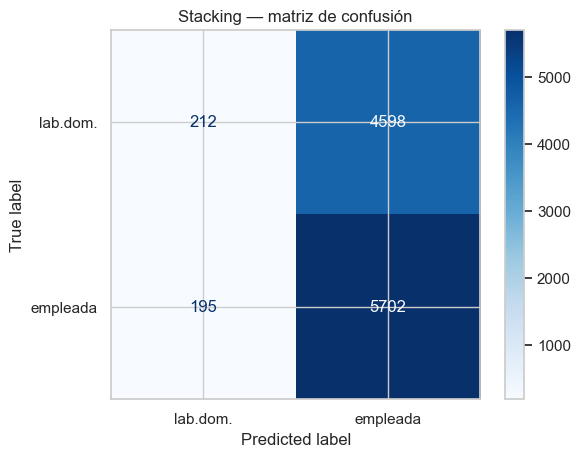

Accuracy CV (stacking): [0.5625 0.5608 0.5569]


In [33]:
# ====================== Stacking ======================

bp_rf, bp_xgb, bp_svm = grid_search.best_params_, grid_XGB.best_params_, grid_SVM.best_params_
estimators = [
    ("rf",    RandomForestClassifier(random_state=42, **bp_rf)),
    ("boost", XGBClassifier(random_state=42, eval_metric="logloss", **bp_xgb)),
    ("svc",   svm.SVC(**bp_svm)),
]
stack = StackingClassifier(estimators=estimators,
                           final_estimator=LogisticRegression(max_iter=1000), cv=3)
stack.fit(X_train_scaled, y_train)
y_pred = stack.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred, labels=stack.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=["lab.dom.", "empleada"]).plot(cmap=plt.cm.Blues)
plt.title("Stacking — matriz de confusión"); plt.show()

# Validación cruzada del stacking 
cv_stack = cross_val_score(stack, X_train_scaled, y_train, cv=3, scoring="accuracy", n_jobs=-1)
print("Accuracy CV (stacking):", cv_stack.round(4))

In [34]:
# ====================== Comparación final: accuracy + eficiencia ======================
best_rf  = grid_search.best_estimator_
best_xgb = grid_XGB.best_estimator_
best_svc = grid_SVM.best_estimator_

modelos = {"Random Forest": best_rf, "XGBoost": best_xgb,
           "SVM (rbf)": best_svc, "Stacking": stack}
filas, preds = [], {}
for nombre, modelo in modelos.items():
    pred, ft, pt = cronometrar(modelo, X_train_scaled, y_train, X_test_scaled)
    preds[nombre] = pred
    filas.append({"Modelo": nombre,
                  "Accuracy": accuracy_score(y_test, pred),
                  "F1 (macro)": f1_score(y_test, pred, average="macro"),
                  "Fit (s)": ft, "Predict (s)": pt})
tabla = pd.DataFrame(filas)
print(f"Baseline = {baseline:.4f}\n")
display(tabla.round({"Accuracy": 4, "F1 (macro)": 4, "Fit (s)": 2, "Predict (s)": 2}))

Baseline = 0.5549



,Modelo,Accuracy,F1 (macro),Fit (s),Predict (s)
0,Random Forest,0.5520,0.3944,1.79,0.07
1,XGBoost,0.5520,0.4017,0.05,0.00
2,SVM (rbf),0.5532,0.3842,14.69,12.79
3,Stacking,0.5523,0.3927,59.78,12.76


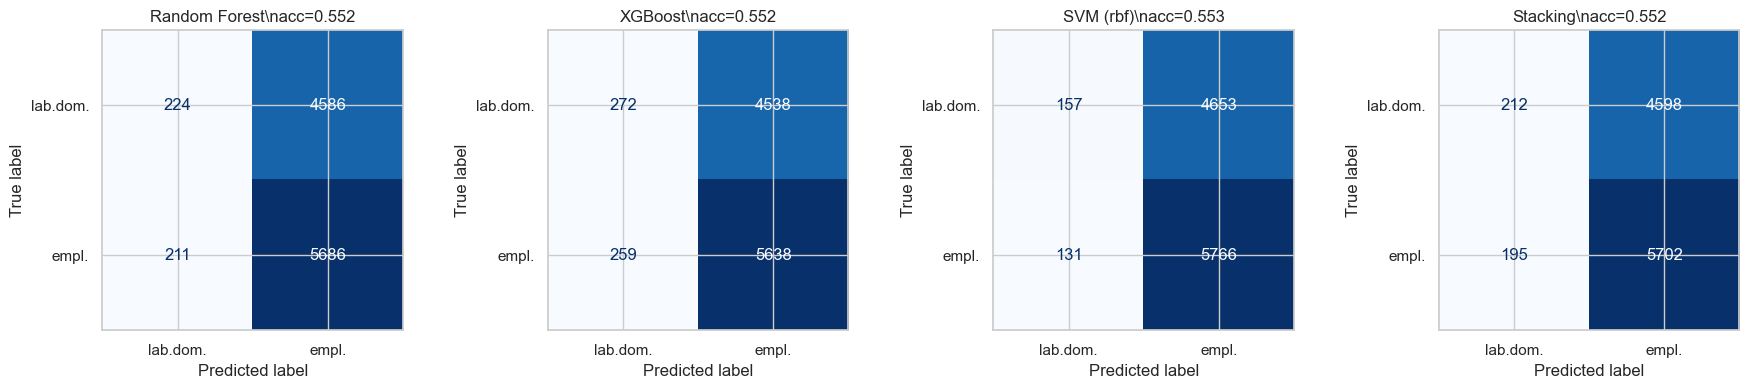

In [35]:
# Matrices de confusión de los cuatro modelos
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (nombre, pred) in zip(axes, preds.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, ax=ax, display_labels=["lab.dom.", "empl."],
        colorbar=False, cmap="Blues")
    ax.set_title(f"{nombre}\\nacc={accuracy_score(y_test, pred):.3f}")
plt.tight_layout(); plt.show()

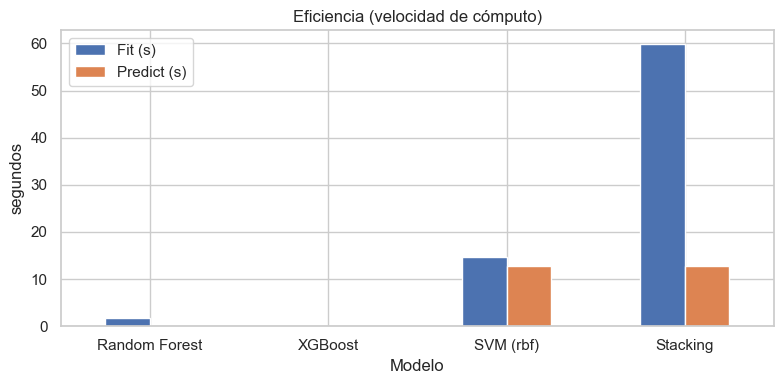

In [36]:
# Eficiencia: tiempo de cómputo de cada modelo
fig, ax = plt.subplots(figsize=(8, 4))
tabla.set_index("Modelo")[["Fit (s)", "Predict (s)"]].plot.bar(ax=ax)
ax.set_ylabel("segundos"); ax.set_title("Eficiencia (velocidad de cómputo)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**R (P5):** Aquí se compararon los resultados de la P4 con XGBoost, Support Vector Machine y Stacking, mirando tanto la matriz de confusión como la eficiencia de cómputo. Para cada modelo se siguió la siguiente estructura: un ajuste base, luego el ajuste con GridSearchCV y su tabla de resultados ordenada por rank_test_score, y finalmente el Stacking armado con la lista de estimators.

En cuanto al desempeño, los cuatro modelos quedan en torno al baseline de 0,5549, e incluso un poco por debajo en el test: Random Forest 0,552, XGBoost 0,552, SVM (rbf) 0,553 y Stacking 0,552. Mirando las matrices de confusión se observa que todos tienden a predecir la clase mayoritaria (madre empleada), la fila de labor doméstica concentra casi todos los errores, lo que se traduce en un recall muy bajo para esa clase y en un F1 macro de apenas 0,38–0,40. Esto es esperable a partir de la presgunta 4: con solo tres factor scores socioemocionales, que como vimos casi no se relacionan con "madre_work", ningún algoritmo logra mejorar lo que se conseguiría simplemente prediciendo siempre la clase más frecuente. Cabe notar que en un dataset algo desbalanceado el accuracy por sí solo engaña, y por eso se reportan también el F1 y la matriz de confusión, que dejan en evidencia que la ganancia sobre el baseline es prácticamente nula. El Stacking, que combina las predicciones de varios modelos, tampoco aporta mejora (su accuracy de validación cruzada queda en 0,56), porque combina modelos que comparten el mismo techo.

Donde sí aparecen diferencias importantes es en la eficiencia, que queda reflejada en los tiempos medidos. Según la materia el gradient boosting (del cual XGBoost es una implementación) suele ser superior a Random Forest, aunque hay que cuidar el sobreajuste mediante hiperparámetros como el shrinkage o tasa de aprendizaje y la profundidad de los árbole, en la práctica XGBoost es el más rápido de todos, con un ajuste de apenas 0,05 segundos, y Random Forest también es veloz (1,79 s). El SVM, en cambio, busca el hiperplano de máximo margen y usa una función kernel para adaptarse a la no linealidad, pero su costo crece de forma aproximadamente cuadrática con el número de observaciones, por lo que con cerca de 36 mil filas es muchísimo más lento: 14,69 segundos para entrenar y otros 12,79 solo para predecir. El Stacking resulta ser el mas costoso de todos, con 59 segundos de entrenamiento, ya que ajusta los tres modelos base más el meta-modelo con validación cruzada interna, y aun así no mejora la precisión.

La conclusión entonces es que como la precisión es indistinguible entre métodos, la elección debería guiarse por la eficiencia, donde para este problema XGBoost y Random Forest superan a SVM y Stacking.

## **PREGUNTA 6:** Clustering sobre IMCE y actividad física

**Enunciado:** Utilice alguno de los métodos de clustering vistos en clases para generar grupos en base a imce y act_fisica. ¿Qué puede concluir de los resultados?

In [37]:
# Variables a usar y estandarización (se normalizará)
X_clu = df_clean[["imce", "act_fisica"]].copy()
Z = StandardScaler().fit_transform(X_clu)

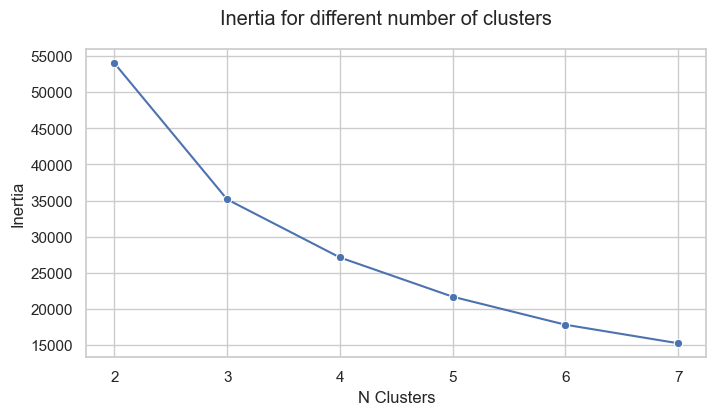

k=2  silhouette=0.311
k=3  silhouette=0.379
k=4  silhouette=0.378
k=5  silhouette=0.369
k=6  silhouette=0.393


In [38]:
# Número de clusters: inercia (método del codo)
total_clusters = 6
param_search = pd.DataFrame({
    "N Clusters": np.arange(2, total_clusters + 2, dtype=int),
    "Inertia": [0.0] * total_clusters,
})
for i in range(total_clusters):
    param_search.loc[i, "Inertia"] = KMeans(
        n_clusters=i + 2, n_init=10, random_state=1).fit(Z).inertia_

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.lineplot(data=param_search, x="N Clusters", y="Inertia", marker="o", ax=ax)
fig.suptitle("Inertia for different number of clusters"); plt.show()

# Se completa con el silhouette score 
samp = np.random.RandomState(0).choice(len(Z), 5000, replace=False)
for k in range(2, 7):
    lab = KMeans(n_clusters=k, n_init=10, random_state=1).fit(Z).labels_
    print(f"k={k}  silhouette={silhouette_score(Z[samp], lab[samp]):.3f}")

In [39]:
#  Solución elegida: k = 3 
kmeans = KMeans(n_clusters=3, random_state=32, max_iter=500, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(Z)
print(df_clean["cluster"].value_counts())

perfil = df_clean.groupby("cluster")[["imce", "act_fisica"]].agg(["mean", "count"]).round(2)
print("\nPerfil por cluster:")
display(perfil)

cluster
1    18664
0    16003
2     5148
Name: count, dtype: int64

Perfil por cluster:


imce        act_fisica       
         mean  count       mean  count
cluster                               
0        2.23  16003       2.25  16003
1        0.01  18664       2.24  18664
2        0.88   5148       4.62   5148

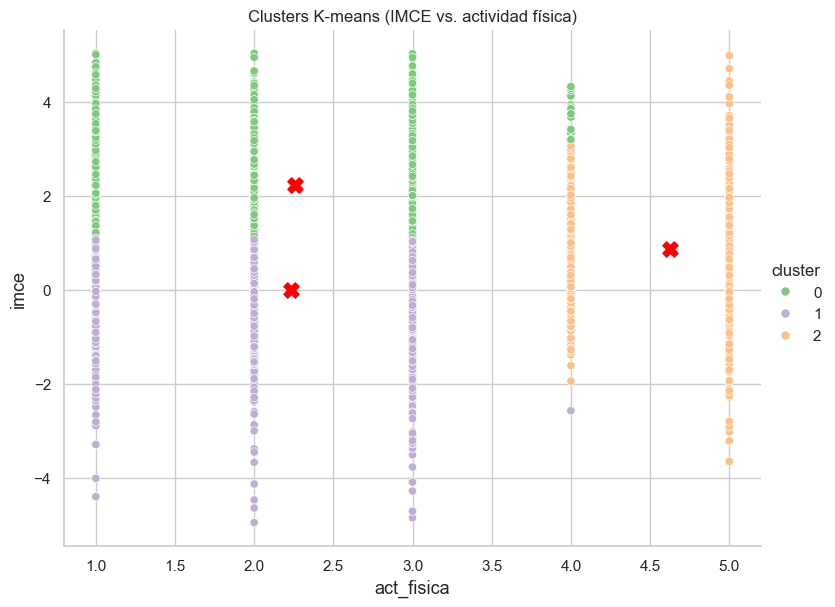

In [40]:
# Visualización de los clusters
centroids = kmeans.cluster_centers_   # en el espacio estandarizado
Data_kmean = df_clean[["imce", "act_fisica", "cluster"]].sample(6000, random_state=0).copy()
sns.relplot(data=Data_kmean, x="act_fisica", y="imce", hue="cluster",
            palette="Accent", kind="scatter", height=6, aspect=1.3)
# centroides de vuelta a la escala original
cent_orig = StandardScaler().fit(X_clu).inverse_transform(centroids)
plt.scatter(cent_orig[:, 1], cent_orig[:, 0], c="red", s=120, marker="X")
plt.xlabel("act_fisica", fontsize=13); plt.ylabel("imce", fontsize=13)
plt.title("Clusters K-means (IMCE vs. actividad física)"); plt.show()

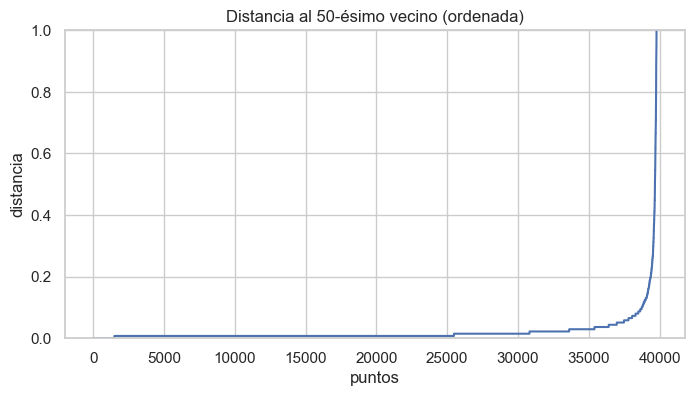

In [41]:
# DBSCAN como contraste
# Elección de eps con la distancia al k-ésimo vecino (k = min_samples), buscando el codo.
k = 50
neighbors = NearestNeighbors(n_neighbors=k).fit(Z)
distances, indices = neighbors.kneighbors(Z)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist); plt.ylim(0, 1)
plt.title(f"Distancia al {k}-ésimo vecino (ordenada)")
plt.xlabel("puntos"); plt.ylabel("distancia"); plt.show()

Number of clusters (DBSCAN): 5 | ruido: 0.4%


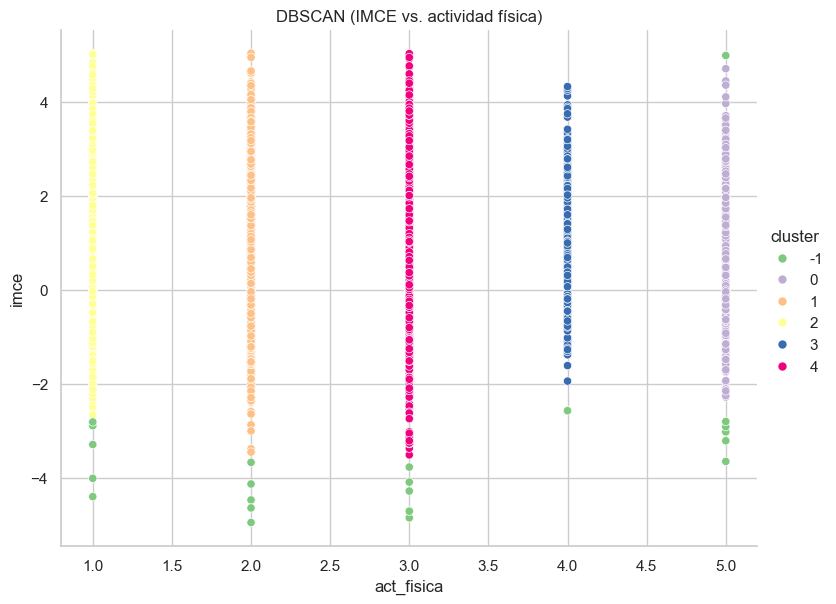


Perfil DBSCAN:


imce        act_fisica       
         mean  count       mean  count
cluster                               
-1      -3.06    146       2.82    146
 0       0.94   3188       5.00   3188
 1       1.04  13967       2.00  13967
 2       1.06   6110       1.00   6110
 3       0.95   2035       4.00   2035
 4       1.03  14369       3.00  14369

In [42]:
# DBSCAN con los hiperparámetros epsilon y MinPts 
dbscan = DBSCAN(eps=0.3, min_samples=50)
dbscan.fit(Z)
labels = dbscan.labels_
n_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)
print(f"Number of clusters (DBSCAN): {n_clusters} | ruido: {(labels==-1).mean():.1%}")

data_dbscan = df_clean[["imce", "act_fisica"]].copy()
data_dbscan["cluster"] = labels
sns.relplot(data=data_dbscan.sample(6000, random_state=0),
            x="act_fisica", y="imce", hue="cluster",
            palette="Accent", kind="scatter", height=6, aspect=1.3)
plt.title("DBSCAN (IMCE vs. actividad física)"); plt.show()

print("\nPerfil DBSCAN:")
display(data_dbscan.groupby("cluster")[["imce", "act_fisica"]].agg(["mean", "count"]).round(2))

**R (P6):** Para generar grupos a partir de `"imce" y "act_fisica" se usó k-means, siguiendo este procedimiento: construir el DataFrame de inercia para distintos números de clusters y graficarlo para buscar el codo. Como es un método basado en distancias, primero se estandarizaron ambas variables.

Para elegir el número de clusters se combinaron dos métricas. La inercia, que mide globalmente la varianza intracluster, muestra un quiebre mas notorio en k=3, donde la caída deja de ser pronunciada (codo). El silhouette score, que reporta la distancia relativa intra versus inter cluster, se mueve en un rango estrecho (entre 0,31 y 0,39) y no marca un óptimo claro: en k=3 toma uno de sus valores más altos (0,379), bastante mejor que en k=2 (0,311). Como el silhouette no discrimina con claridad, el criterio que pesa es el codo de la inercia, que sí señala k=3, reforzado por que tres grupos entregan una partición simple e interpretable. El perfil resultante es: un grupo de "niños activos", con actividad física alta (4,62) e IMCE moderado (0,88), que reúne a 5.148 niños; un grupo de "peso normal y poco activos", con IMCE prácticamente 0 (0,01) y actividad media (2,24), el más numeroso con 18.664; y un grupo de "IMCE alto y poco activos", con un IMCE promedio de 2,23 que apunta a sobrepeso y actividad baja (2,25), con 16.003 niños. En el gráfico de los clusters se ve bien esta lógica, los dos grupos de baja actividad (IMCE alto y peso normal) quedan uno sobre otro en la misma columna de actividad física y se separan solo por el IMCE, mientras que el grupo activo se desprende hacia la derecha, en los niveles altos de actividad. Lo que se concluye es que el clustering reproduce un patrón esperable en salud infantil, el grupo de mayor IMCE coincide con baja actividad física, mientras que el grupo más activo mantiene un IMCE bastante más contenido. Hay que recordar que esto es aprendizaje no supervisado, así que describe co-ocurrencia entre actividad y peso, no causalidad.

Como contraste se aplicó también DBSCAN, siguiendo ese enfoque, el eps se eligió a partir de la distancia al k-ésimo vecino con "NearestNeighbors", y se fijó **min_samples** . El resultado muestra algo importante: con **eps=0.3** y **min_samples=50**, DBSCAN entrega 5 grupos y solo un 0,4% de ruido, pero al ser un método basado en densidad se "pega" a los niveles discretos de "act_fisica" y termina formando una banda por cada frecuencia de actividad (1, 2, 3, 4 y 5), todas con un IMCE promedio parecido (alrededor de 1,0), y deja los casos de IMCE extremo (media -3,06) como ruido, es decir, no logra aislar el grupo de IMCE alto que sí separa k-means. Esto muestra que los resultados son sensibles tanto a la data como a los hiperparámetros. Para esta tarea k-means resultó más útil ya que separa a los niños según su IMCE, por lo que es la partición que se usa a continuación en la P7.

## **PREGUNTA 7**: Re-estimación del mejor modelo en el grupo de mayor IMCE

**Enunciado.** Elija el grupo con mayor IMCE promedio (P6) y estime nuevamente su mejor modelo de P5. ¿Qué puede concluir de sus resultados?

In [43]:
# Cluster con mayor IMCE promedio
cl_alto = df_clean.groupby("cluster")["imce"].mean().idxmax()
print(f"Cluster de mayor IMCE promedio: {cl_alto} "
      f"(IMCE medio = {df_clean.loc[df_clean.cluster==cl_alto,'imce'].mean():.2f})")

# Submuestra: ese cluster, excluyendo madre desempleada
sub = df_clean[(df_clean["cluster"] == cl_alto) & (df_clean["madre_work"] != 0)].copy()
y_s = (sub["madre_work"] == 1).astype(int)
X_s = sub[["Curiosidad", "Afecto", "Habilid_social"]]
print("N submuestra:", len(sub),
      "| baseline:", round(max(y_s.mean(), 1 - y_s.mean()), 4))

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_s, y_s, test_size=0.3, random_state=42)
sc_s = StandardScaler()
Xs_train_sc = sc_s.fit_transform(Xs_train)
Xs_test_sc = sc_s.transform(Xs_test)

Cluster de mayor IMCE promedio: 0 (IMCE medio = 2.23)
N submuestra: 14293 | baseline: 0.5676


Accuracy submuestra IMCE alto: 0.5630
Accuracy muestra completa P5 : 0.5520

                 precision    recall  f1-score   support

labor doméstica       0.53      0.05      0.09      1884
       empleada       0.56      0.96      0.71      2404

       accuracy                           0.56      4288
      macro avg       0.55      0.51      0.40      4288
   weighted avg       0.55      0.56      0.44      4288



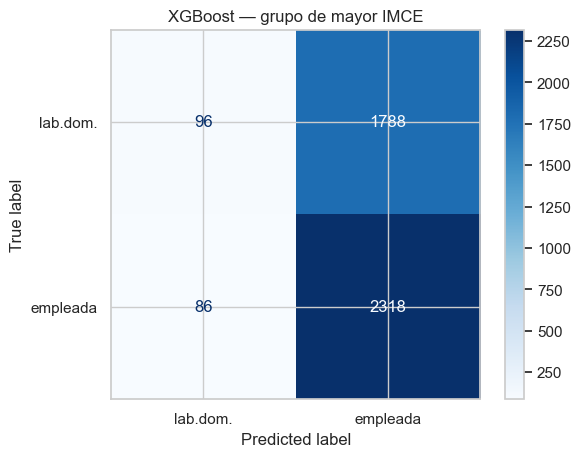

In [44]:
# Re-estimamos el mejor modelo de la P5 (por eficiencia/accuracy: XGBoost) en la submuestra
mejor = XGBClassifier(random_state=42, eval_metric="logloss", **grid_XGB.best_params_)
mejor.fit(Xs_train_sc, ys_train)
pred_s = mejor.predict(Xs_test_sc)

acc_sub  = accuracy_score(ys_test, pred_s)
acc_full = tabla.loc[tabla.Modelo == "XGBoost", "Accuracy"].values[0]
print(f"Accuracy submuestra IMCE alto: {acc_sub:.4f}")
print(f"Accuracy muestra completa P5 : {acc_full:.4f}\n")
print(classification_report(ys_test, pred_s, target_names=["labor doméstica", "empleada"]))

cm = confusion_matrix(ys_test, pred_s, labels=mejor.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=["lab.dom.", "empleada"]).plot(cmap=plt.cm.Blues)
plt.title("XGBoost — grupo de mayor IMCE"); plt.show()

**R (P7).** El grupo con mayor IMCE promedio es el cluster de IMCE alto y baja actividad identificado en la P6, con una media de 2,23. Ese cluster reúne 16.003 niños, al excluir a las desempleadas quedan 14.293, con un baseline algo más alto que el de la muestra completa (0,5676). Sobre esa submuestra se volvió a estimar el mejor modelo de la P5, que por su combinación de precisión y eficiencia fue XGBoost, manteniendo el mismo target binario.

El resultado es un accuracy de 0,563, que vuelve a quedar por debajo del baseline de esa submuestra (0,5676) y muy parecido al del modelo completo (0,552). El classification report muestra el mismo comportamiento de antes con un recall de 0,96 para "empleada" y de apenas 0,05 para "labor doméstica", o sea el modelo sigue prediciendo esencialmente la clase mayoritaria.

Lo que se concluye es que restringir el análisis al subgrupo de mayor IMCE no agrega poder predictivo sobre "madre_work", lo que confirma lo visto en la P4 y la P5, donde la falta de señal no se debía a heterogeneidad escondida entre grupos de peso, sino a que los features socioemocionales no contienen información sobre el empleo de la madre. Además, al trabajar con una muestra más chica, y en línea con el trade-off sesgo-varianza, la estimación se vuelve más variable y por lo tanto menos estable, sin ninguna compensación en accuracy. Por lo tanto, no hay ganancia en estimar el modelo solo para el grupo de IMCE alto.

## **PREGUNTA 8**: Análisis de texto sobre narrative (contraste con P5)

**Enunciado.** Revise Sentiment_Analysis.ipynb. Considere la variable narrative. Use las funciones para tokenizar los textos y entrene un modelo adecuado para contrastar con P5 (SVC), excluyendo las variables sk. Compare y discuta sus resultados.

In [45]:
# Stopwords en español 
try:
    SPANISH_SW = set(stopwords.words("spanish"))
except LookupError:
    nltk.download("stopwords")
    SPANISH_SW = set(stopwords.words("spanish"))


def texto_a_palabras(texto):
    solo_letras = re.sub(r"[^a-záéíóúñ ]", " ", str(texto).lower())
    palabras = solo_letras.split()
    significativas = [w for w in palabras if w not in SPANISH_SW and len(w) > 2]
    return " ".join(significativas)

In [46]:
# Mismo target que P5 (binario, excluye desempleadas). Features = SOLO texto (sin sk).
data_txt = df_clean[df_clean["madre_work"] != 0].copy()
y_txt = (data_txt["madre_work"] == 1).astype(int)
X_txt = data_txt["narrative"].apply(texto_a_palabras)

xt_tr, xt_te, yt_tr, yt_te = train_test_split(
    X_txt, y_txt, test_size=0.25, stratify=y_txt, random_state=RANDOM_STATE)

# Vectorización Bag-of-Words (CountVectorizer)
vect = CountVectorizer(ngram_range=(1, 2), min_df=5, max_features=3000)
Xt_tr = vect.fit_transform(xt_tr)
Xt_te = vect.transform(xt_te)
print("Tamaño del vocabulario:", len(vect.get_feature_names_out()))

Tamaño del vocabulario: 1221


SVC (texto) accuracy: 0.5445  (fit 2192.7s)
Baseline:             0.5549

                 precision    recall  f1-score   support

labor doméstica       0.46      0.12      0.19      3972
       empleada       0.56      0.88      0.68      4950

       accuracy                           0.54      8922
      macro avg       0.51      0.50      0.44      8922
   weighted avg       0.51      0.54      0.46      8922



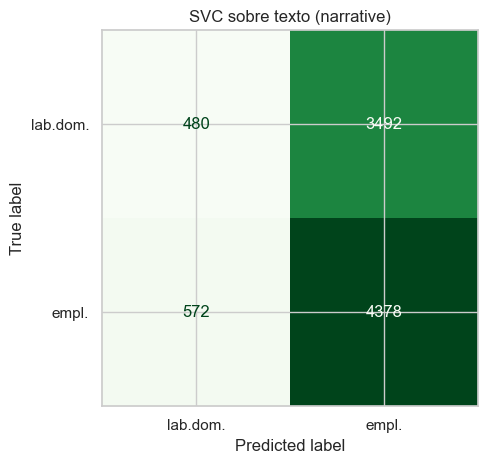

In [47]:
# Modelo SVC (lineal) sobre el texto — para contrastar con el SVM de la P5
t0 = time.time()
svc_txt = svm.SVC(kernel="linear", random_state=10)
svc_txt.fit(Xt_tr, yt_tr)
pred_txt = svc_txt.predict(Xt_te)
print(f"SVC (texto) accuracy: {accuracy_score(yt_te, pred_txt):.4f}  "
      f"(fit {time.time()-t0:.1f}s)")
print(f"Baseline:             {max(y_txt.mean(), 1 - y_txt.mean()):.4f}")
print()
print(classification_report(yt_te, pred_txt,
      target_names=["labor doméstica", "empleada"]))

ConfusionMatrixDisplay.from_predictions(yt_te, pred_txt,
        display_labels=["lab.dom.","empl."], cmap="Greens", colorbar=False)
plt.title("SVC sobre texto (narrative)"); plt.tight_layout(); plt.show()

In [48]:
# Comparación directa: SVM sobre factores (P5) vs SVC sobre texto (P8)
comp = pd.DataFrame({
    "Enfoque": ["P5: SVM sobre 3 factor scores", "P8: SVC sobre texto (narrative)"],
    "Accuracy": [tabla.loc[tabla.Modelo=="SVM (rbf)","Accuracy"].values[0],
                 accuracy_score(yt_te, pred_txt)],
}).round(4)
comp["Baseline"] = round(baseline, 4)
display(comp)

,Enfoque,Accuracy,Baseline
0,P5: SVM sobre 3 factor scores,0.5532,0.5549
1,P8: SVC sobre texto (narrative),0.5445,0.5549


**R (P8)**. Para esta última parte se trabajó con la variable de texto narrative, siguiendo el procesamiento siguiente: se pasó todo a minúsculas, se limpió con expresiones regulares y se quitaron las stopwords en español, para luego tokenizar. Una vez limpio el texto, se vectorizó con un esquema de bolsa de palabras (CountVectorizer), que transforma cada narrativa en una matriz documento-término. En el fondo, esa matriz es el conjunto de features con que se alimenta el clasificador, de modo que el problema se reduce nuevamente a una clasificación supervisada. Para que el contraste con la P5 fuera directo se entrenó un SVM con kernel lineal (svm.SVC), que busca el hiperplano de máximo margen y es el adecuado para texto, sobre el mismo target madre_work, excluyendo las desempleadas y, sobre todo, excluyendo las variables sk como pide el enunciado, para que la predicción dependa únicamente del texto.

El SVM de texto obtiene un accuracy de 0,544, es decir por debajo del baseline de 0,5549 y muy parecido al SVM de la P5 sobre los factor scores (0,553). El classification report confirma el mismo patrón: recall de 0,88 para "empleada" y de solo 0,12 para "labor doméstica", de nuevo prediciendo sobre todo la clase mayoritaria. Esto se podría decir que igual es esperable como narrative es un texto generado a partir de los mismos ítems sk1–sk13, termina codificando esencialmente la misma información socioemocional que los factores latentes, solo que en otra representación. Por eso ambos enfoques, el numérico-factorial y el textual, comparten el mismo techo predictivo y ninguno logra anticipar el trabajo de la madre.

Como conclusión general de la tarea, a través de tres representaciones distintas de las habilidades socioemocionales del niño (los ítems crudos, los factores latentes del CFA y su narrativa en texto) el resultado es siempre el mismo, estas habilidades no predicen madre_work. Esto es coherente con que el machine learning optimiza la predicción fuera de muestra y no establece relaciones causales, lo que el ejercicio muestra, con herramientas de SEM, clasificación supervisada, clustering y procesamiento de texto, es que la señal simplemente no está en estas variables. Las diferencias relevantes entre métodos terminan apareciendo en la eficiencia de cómputo y no en la capacidad predictiva.